In [ ]:
!pip -q install pandas requests openpyxl

import requests
import json
import pandas as pd
from datetime import datetime
from pathlib import Path

In [ ]:
url = "https://raw.githubusercontent.com/maritaca-ai/oab-bench/main/data/oab_bench/question.jsonl"

response = requests.get(url)
response.raise_for_status()

linhas = response.text.strip().split("\n")
questoes = [json.loads(linha) for linha in linhas if linha.strip()]

print(f"Total de questões carregadas: {len(questoes)}")
print("Primeiro registro:")
print(questoes[0].keys())

Total de questões carregadas: 210
Primeiro registro:
dict_keys(['question_id', 'category', 'statement', 'turns', 'values', 'system'])


In [ ]:
for i, q in enumerate(questoes, start=1):
    q["numero_global"] = i

In [ ]:
minhas_questoes = [q for q in questoes if 119 <= q["numero_global"] <= 130]

print(f"Quantidade de questões do seu lote: {len(minhas_questoes)}")
for q in minhas_questoes:
    print(q["numero_global"], q["question_id"], q["category"])

Quantidade de questões do seu lote: 12
119 42_direito_empresarial_questao_3 42_direito_empresarial
120 42_direito_empresarial_questao_4 42_direito_empresarial
121 42_direito_civil_peca_profissional 42_direito_civil
122 42_direito_civil_questao_1 42_direito_civil
123 42_direito_civil_questao_2 42_direito_civil
124 42_direito_civil_questao_3 42_direito_civil
125 42_direito_civil_questao_4 42_direito_civil
126 42_direito_administrativo_peca_profissional 42_direito_administrativo
127 42_direito_administrativo_questao_1 42_direito_administrativo
128 42_direito_administrativo_questao_2 42_direito_administrativo
129 42_direito_administrativo_questao_3 42_direito_administrativo
130 42_direito_administrativo_questao_4 42_direito_administrativo


In [ ]:
for q in minhas_questoes:
    print("=" * 100)
    print("NÚMERO:", q["numero_global"])
    print("QUESTION_ID:", q["question_id"])
    print("CATEGORY:", q["category"])
    print("ENUNCIADO:")
    print(q["statement"])
    print("ITENS:")
    for i, turno in enumerate(q.get("turns", []), start=1):
        print(f"  {i}. {turno}")

NÚMERO: 119
QUESTION_ID: 42_direito_empresarial_questao_3
CATEGORY: 42_direito_empresarial
ENUNCIADO:
QUESTÃO 3
As sociedades empresárias do tipo limitada Madeireira Saquarema Ltda. e Construtora Maricá Ltda. pretendem se unir para formar sociedade nova, com a extinção de ambas após a conclusão da operação.
Sobre a hipótese apresentada, responda aos itens a seguir.
Obs .: o(a) examinando(a) deve fundamentar suas respostas. A mera citação do dispositivo legal não confere pontuação.
ITENS:
  1. A) Qual o órgão competente para decidir sobre a operação e qual o quórum para que ela seja aprovada em cada sociedade? Justifique. (Valor: 0,65)
  2. B) Sendo apresentados os laudos de avaliação dos peritos nomeados para a avaliação do patrimônio de cada sociedade, como deverão proceder os administradores? Justifique. (Valor: 0,60)
NÚMERO: 120
QUESTION_ID: 42_direito_empresarial_questao_4
CATEGORY: 42_direito_empresarial
ENUNCIADO:
QUESTÃO 4
Floresta de Azevedo, sócia da sociedade Floricultura Sor

In [ ]:
linhas_respostas = []

for q in minhas_questoes:
    for modelo in ["ChatGPT", "Gemini", "Grok"]:
        linhas_respostas.append({
            "numero_global": q["numero_global"],
            "question_id": q["question_id"],
            "modelo": modelo,
            "prompt_utilizado": "",
            "resposta_modelo": "",
        })

df_respostas = pd.DataFrame(linhas_respostas)
df_respostas.head()

,numero_global,question_id,modelo,prompt_utilizado,resposta_modelo
0,119,42_direito_empresarial_questao_3,ChatGPT,,
1,119,42_direito_empresarial_questao_3,Gemini,,
2,119,42_direito_empresarial_questao_3,Grok,,
3,120,42_direito_empresarial_questao_4,ChatGPT,,
4,120,42_direito_empresarial_questao_4,Gemini,,


In [ ]:
import pandas as pd


df_excel = pd.read_excel("respostas.xlsx")

print(df_excel.columns.tolist())
print(df_excel.head())


df_excel = df_excel.rename(columns={
    "numero_global": "numero_global",
    "question_id": "question_id",
    "modelo": "modelo",
    "prompt_utilizado": "prompt_utilizado",
    "resposta_modelo": "resposta_modelo"
})

df_excel["numero_global"] = pd.to_numeric(df_excel["numero_global"], errors="coerce")

df_respostas = df_respostas.drop(columns=["prompt_utilizado", "resposta_modelo"], errors="ignore")

df_respostas = df_respostas.merge(
    df_excel[["numero_global", "question_id", "modelo", "prompt_utilizado", "resposta_modelo"]],
    on=["numero_global", "question_id", "modelo"],
    how="left"
)

df_respostas.head()

['numero_global', 'question_id', 'modelo', 'prompt_utilizado', 'resposta_modelo']
   numero_global                       question_id   modelo  \
0            119  42_direito_empresarial_questao_3  ChatGPT   
1            119  42_direito_empresarial_questao_3   Gemini   
2            119  42_direito_empresarial_questao_3     Grok   
3            120  42_direito_empresarial_questao_4  ChatGPT   
4            120  42_direito_empresarial_questao_4   Gemini   

                                    prompt_utilizado  \
0  Você é um candidato da segunda fase da OAB.\nR...   
1  Você é um candidato da segunda fase da OAB.\nR...   
2  Você é um candidato da segunda fase da OAB.\nR...   
3  Você é um candidato da segunda fase da OAB.\nR...   
4  Você é um candidato da segunda fase da OAB.\nR...   

                                     resposta_modelo  
0  Tese jurídica: A operação descrita configura h...  
1  A operação societária pretendida entre a Madei...  
2  1. A) O órgão competente para deci

,numero_global,question_id,modelo,prompt_utilizado,resposta_modelo
0,119,42_direito_empresarial_questao_3,ChatGPT,Você é um candidato da segunda fase da OAB.\nR...,Tese jurídica: A operação descrita configura h...
1,119,42_direito_empresarial_questao_3,Gemini,Você é um candidato da segunda fase da OAB.\nR...,A operação societária pretendida entre a Madei...
2,119,42_direito_empresarial_questao_3,Grok,Você é um candidato da segunda fase da OAB.\nR...,1. A) O órgão competente para decidir sobre a ...
3,120,42_direito_empresarial_questao_4,ChatGPT,Você é um candidato da segunda fase da OAB.\nR...,Tese jurídica: A deliberação assemblear é pass...
4,120,42_direito_empresarial_questao_4,Gemini,Você é um candidato da segunda fase da OAB.\nR...,"A questão versa sobre o Direito Societário, es..."


In [ ]:
linhas_avaliacao = []

for q in minhas_questoes:
    for modelo in ["ChatGPT", "Gemini", "Grok"]:
        linhas_avaliacao.append({
            "numero_global": q["numero_global"],
            "question_id": q["question_id"],
            "modelo": modelo,
            "clareza": "",
            "precisao_juridica": "",
            "fundamentacao_legal": "",
            "coesao_argumentativa": "",
            "completude": "",
            "adequacao_ao_caso": "",
            "seguranca_tecnica": "",
            "pontuacao_total": "",
            "comentario_analitico": ""
        })

df_avaliacao = pd.DataFrame(linhas_avaliacao)
df_avaliacao.head()

,numero_global,question_id,modelo,clareza,precisao_juridica,fundamentacao_legal,coesao_argumentativa,completude,adequacao_ao_caso,seguranca_tecnica,pontuacao_total,comentario_analitico
0,119,42_direito_empresarial_questao_3,ChatGPT,,,,,,,,,
1,119,42_direito_empresarial_questao_3,Gemini,,,,,,,,,
2,119,42_direito_empresarial_questao_3,Grok,,,,,,,,,
3,120,42_direito_empresarial_questao_4,ChatGPT,,,,,,,,,
4,120,42_direito_empresarial_questao_4,Gemini,,,,,,,,,


In [ ]:
curadoria_preenchida = [
    [119, "42_direito_empresarial_questao_3", "direito_empresarial", "42", "direito_empresarial", "N3 — Analítica", "Operações societárias em sociedade limitada", "Código Civil, arts. 1.119 e 1.120", "Código Civil, arts. 1.071 e 1.076", "Questão sobre fusão de sociedades limitadas, exigindo definição do órgão deliberativo, quórum e procedimento após os laudos de avaliação."],
    [120, "42_direito_empresarial_questao_4", "direito_empresarial", "42", "direito_empresarial", "N3 — Analítica", "Deliberações sociais e representação em assembleia", "Código Civil, art. 1.074", "Código Civil, arts. 1.072 e 1.076", "Exige diferenciar quórum de instalação e quórum de deliberação, além da validade da representação por mandatário em assembleia de limitada."],
    [121, "42_direito_civil_peca_profissional", "direito_civil", "42", "direito_civil", "N4 — Estratégica", "Direito do consumidor bancário e recurso de apelação", "Código de Processo Civil, arts. 1.009 a 1.014", "CDC, arts. 6º, 14, 47; CPC, art. 80", "Peça prático-profissional. Exige identificação do recurso cabível, tempestividade, revisão contratual, litigância de má-fé e proteção da consumidora idosa."],
    [122, "42_direito_civil_questao_1", "direito_civil", "42", "direito_civil", "N3 — Analítica", "Alimentos avoengos", "Código Civil, arts. 1.696 e 1.698", "Súmula 596 do STJ", "Questão de alimentos com foco na natureza subsidiária e complementar da obrigação avoenga e na forma correta de formular o pedido em juízo."],
    [123, "42_direito_civil_questao_2", "direito_civil", "42", "direito_civil", "N2 — Interpretativa", "Nome civil e união estável registrada", "Lei 6.015/1973, art. 57", "Lei 14.382/2022; Código Civil, art. 16", "Trata da inclusão de sobrenome do companheiro em união estável registrada, por via extrajudicial, com análise de consentimento e prazo."],
    [124, "42_direito_civil_questao_3", "direito_civil", "42", "direito_civil", "N3 — Analítica", "Sucessões: colação e sonegados", "Código Civil, arts. 2.002 a 2.006", "CPC, art. 618; Código Civil, arts. 1.992 e 1.993", "Exige compreender a presunção de adiantamento de legítima e as medidas cabíveis diante da omissão de bem no inventário."],
    [125, "42_direito_civil_questao_4", "direito_civil", "42", "direito_civil", "N3 — Analítica", "Responsabilidade civil por fato do produto", "CDC, arts. 12 e 13", "CPC, arts. 337, XI, e 339", "Questão de Direito do Consumidor aplicada: defeito de fabricação, ilegitimidade passiva do comerciante e técnica processual para exclusão do polo passivo."],
    [126, "42_direito_administrativo_peca_profissional", "direito_administrativo", "42", "direito_administrativo", "N4 — Estratégica", "Intervenção do Estado na propriedade e responsabilidade civil estatal", "Constituição Federal, art. 5º, XXV", "Constituição Federal, art. 37, § 6º; Lei 8.080/1990, art. 15, XIII; CPC, arts. 1.009 e ss.", "Peça prático-profissional sobre requisição administrativa, dever de indenizar e apelação contra sentença improcedente."],
    [127, "42_direito_administrativo_questao_1", "direito_administrativo", "42", "direito_administrativo", "N2 — Interpretativa", "Processo administrativo disciplinar e revisão", "Lei 8.112/1990, arts. 174 e 176", "Lei 8.112/1990, arts. 125 e 126", "Exige distinguir revisão do PAD e independência entre instâncias penal e administrativa."],
    [128, "42_direito_administrativo_questao_2", "direito_administrativo", "42", "direito_administrativo", "N3 — Analítica", "Proteção de dados pessoais na Administração Pública", "LGPD, arts. 7º e 8º", "LGPD, arts. 18 e 26", "Questão sobre base legal para compartilhamento entre controladores e revogação do consentimento pelo titular."],
    [129, "42_direito_administrativo_questao_3", "direito_administrativo", "42", "direito_administrativo", "N2 — Interpretativa", "Contratação direta de imóvel e planejamento da contratação", "Lei 14.133/2021, art. 74, V", "Lei 14.133/2021, arts. 18 e 44", "Exige conhecer a inexigibilidade para compra/locação de imóvel singular e a necessidade de ETP comparando locação e aquisição."],
    [130, "42_direito_administrativo_questao_4", "direito_administrativo", "42", "direito_administrativo", "N2 — Interpretativa", "Desapropriação por utilidade pública", "Decreto-Lei 3.365/1941, arts. 7º e 20", "Constituição Federal, art. 5º, XXIV", "Questão sobre ingresso prévio no imóvel para inspeção e limites das matérias alegáveis em contestação na ação expropriatória."]
]

colunas = [
    "numero_global",
    "question_id",
    "category",
    "edicao_oab",
    "area_dataset",
    "dificuldade",
    "subarea",
    "referencia_legal_principal",
    "referencia_legal_secundaria",
    "observacoes_curadoria"
]

df_curadoria = pd.DataFrame(curadoria_preenchida, columns=colunas)
df_curadoria

,numero_global,question_id,category,edicao_oab,area_dataset,dificuldade,subarea,referencia_legal_principal,referencia_legal_secundaria,observacoes_curadoria
0,119,42_direito_empresarial_questao_3,direito_empresarial,42,direito_empresarial,N3 — Analítica,Operações societárias em sociedade limitada,"Código Civil, arts. 1.119 e 1.120","Código Civil, arts. 1.071 e 1.076","Questão sobre fusão de sociedades limitadas, e..."
1,120,42_direito_empresarial_questao_4,direito_empresarial,42,direito_empresarial,N3 — Analítica,Deliberações sociais e representação em assemb...,"Código Civil, art. 1.074","Código Civil, arts. 1.072 e 1.076",Exige diferenciar quórum de instalação e quóru...
2,121,42_direito_civil_peca_profissional,direito_civil,42,direito_civil,N4 — Estratégica,Direito do consumidor bancário e recurso de ap...,"Código de Processo Civil, arts. 1.009 a 1.014","CDC, arts. 6º, 14, 47; CPC, art. 80",Peça prático-profissional. Exige identificação...
3,122,42_direito_civil_questao_1,direito_civil,42,direito_civil,N3 — Analítica,Alimentos avoengos,"Código Civil, arts. 1.696 e 1.698",Súmula 596 do STJ,Questão de alimentos com foco na natureza subs...
4,123,42_direito_civil_questao_2,direito_civil,42,direito_civil,N2 — Interpretativa,Nome civil e união estável registrada,"Lei 6.015/1973, art. 57","Lei 14.382/2022; Código Civil, art. 16",Trata da inclusão de sobrenome do companheiro ...
5,124,42_direito_civil_questao_3,direito_civil,42,direito_civil,N3 — Analítica,Sucessões: colação e sonegados,"Código Civil, arts. 2.002 a 2.006","CPC, art. 618; Código Civil, arts. 1.992 e 1.993",Exige compreender a presunção de adiantamento ...
6,125,42_direito_civil_questao_4,direito_civil,42,direito_civil,N3 — Analítica,Responsabilidade civil por fato do produto,"CDC, arts. 12 e 13","CPC, arts. 337, XI, e 339",Questão de Direito do Consumidor aplicada: def...
7,126,42_direito_administrativo_peca_profissional,direito_administrativo,42,direito_administrativo,N4 — Estratégica,Intervenção do Estado na propriedade e respons...,"Constituição Federal, art. 5º, XXV","Constituição Federal, art. 37, § 6º; Lei 8.080...",Peça prático-profissional sobre requisição adm...
8,127,42_direito_administrativo_questao_1,direito_administrativo,42,direito_administrativo,N2 — Interpretativa,Processo administrativo disciplinar e revisão,"Lei 8.112/1990, arts. 174 e 176","Lei 8.112/1990, arts. 125 e 126",Exige distinguir revisão do PAD e independênci...
9,128,42_direito_administrativo_questao_2,direito_administrativo,42,direito_administrativo,N3 — Analítica,Proteção de dados pessoais na Administração Pú...,"LGPD, arts. 7º e 8º","LGPD, arts. 18 e 26",Questão sobre base legal para compartilhamento...


In [ ]:
avaliacoes = [
    # 119
    {
        "numero_global": 119, "question_id": "42_direito_empresarial_questao_3", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 3, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 3,
        "comentario_analitico": "A resposta apresenta excelente organização, clareza e completude, com adequada descrição do instituto da fusão e dos procedimentos societários. Contudo, há imprecisão jurídica relevante quanto ao quórum de aprovação, ao adotar o critério de três quartos do capital social, em desacordo com a legislação atualizada pela Lei nº 14.451/2022, o que reduz a segurança técnica da resposta."
    },
    {
        "numero_global": 119, "question_id": "42_direito_empresarial_questao_3", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 3, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 3,
        "comentario_analitico": "A resposta apresenta elevada clareza, boa fundamentação legal e estrutura argumentativa consistente. Todavia, reproduz entendimento parcialmente desatualizado quanto ao quórum de aprovação da fusão, mantendo o critério de três quartos do capital social. Apesar disso, demonstra maior esforço de fundamentação normativa que as demais, embora ainda incorra em imprecisão jurídica relevante."
    },
    {
        "numero_global": 119, "question_id": "42_direito_empresarial_questao_3", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "A resposta apresenta elevado nível técnico, com correta identificação da operação de fusão, fundamentação legal adequada e, principalmente, aplicação atualizada da legislação ao adotar o critério de maioria absoluta conforme a Lei nº 14.451/2022. Demonstra precisão jurídica, completude e alta segurança técnica."
    },

    # 120
    {
        "numero_global": 120, "question_id": "42_direito_empresarial_questao_4", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 2, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 2,
        "seguranca_tecnica": 2,
        "comentario_analitico": "A resposta apresenta boa clareza e organização, porém incorre em erro jurídico relevante ao considerar válida a instalação da assembleia com quórum inferior ao exigido em primeira convocação. Tal equívoco compromete a adequação ao caso concreto e a segurança técnica, embora a estrutura argumentativa seja consistente."
    },
    {
        "numero_global": 120, "question_id": "42_direito_empresarial_questao_4", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 3, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 3,
        "seguranca_tecnica": 3,
        "comentario_analitico": "A resposta apresenta boa clareza e estrutura argumentativa, mas adota interpretação inadequada ao tentar validar a assembleia com quórum inferior ao legal, sob argumento de ausência de prejuízo. Tal entendimento não encontra respaldo direto na legislação, reduzindo a precisão jurídica e a segurança técnica."
    },
    {
        "numero_global": 120, "question_id": "42_direito_empresarial_questao_4", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "A resposta apresenta elevada precisão jurídica ao identificar corretamente a irregularidade da assembleia em primeira convocação, com base no quórum legal de três quartos do capital social. Demonstra domínio técnico, adequada aplicação normativa e alta segurança jurídica."
    },

    # 121
    {
        "numero_global": 121, "question_id": "42_direito_civil_peca_profissional", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "A resposta apresenta estrutura adequada de peça processual, correta identificação do recurso cabível e fundamentação consistente no Código de Defesa do Consumidor. Demonstra clareza, completude e elevada segurança técnica."
    },
    {
        "numero_global": 121, "question_id": "42_direito_civil_peca_profissional", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "A resposta apresenta excelente organização e completude, com correta estrutura de apelação e adequada fundamentação jurídica. Demonstra domínio técnico e aderência integral ao caso proposto."
    },
    {
        "numero_global": 121, "question_id": "42_direito_civil_peca_profissional", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "A resposta apresenta excelente estrutura de peça processual, com correta identificação da apelação, adequada organização formal e enfrentamento completo dos pontos da sentença. A fundamentação jurídica é consistente, com uso apropriado do Código de Defesa do Consumidor, Estatuto do Idoso e normas processuais. Demonstra elevada precisão técnica, clareza e segurança jurídica, com plena adequação ao caso concreto."
    },

    # 122
    {
        "numero_global": 122, "question_id": "42_direito_civil_questao_1", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta clara e juridicamente correta, com adequada explicação da natureza subsidiária dos alimentos avoengos e correta orientação quanto à formulação do pedido. Poderia apresentar fundamentação legal mais explícita."
    },
    {
        "numero_global": 122, "question_id": "42_direito_civil_questao_1", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta completa, com correta identificação da natureza subsidiária da obrigação avoenga, adequada fundamentação legal e correta indicação do litisconsórcio. Demonstra elevado domínio técnico."
    },
    {
        "numero_global": 122, "question_id": "42_direito_civil_questao_1", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta tecnicamente completa e precisa, com detalhamento consistente da obrigação subsidiária dos avós e correta formulação do pedido. Apresenta excelente fundamentação e segurança jurídica."
    },

    # 123
    {
        "numero_global": 123, "question_id": "42_direito_civil_questao_2", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 4, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 4,
        "comentario_analitico": "Resposta correta e bem estruturada, mas com fundamentação normativa menos precisa ao priorizar atos infralegais em vez de dispositivos legais diretos."
    },
    {
        "numero_global": 123, "question_id": "42_direito_civil_questao_2", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta completa e juridicamente precisa, com excelente fundamentação na legislação atual, especialmente após a Lei nº 14.382/2022."
    },
    {
        "numero_global": 123, "question_id": "42_direito_civil_questao_2", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta altamente técnica, com fundamentação legal detalhada e aplicação correta da legislação registral atualizada, demonstrando elevado domínio jurídico."
    },

    # 124
    {
        "numero_global": 124, "question_id": "42_direito_civil_questao_3", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta correta e bem estruturada, com adequada explicação da colação e das consequências da omissão de bens no inventário, embora com fundamentação legal menos detalhada."
    },
    {
        "numero_global": 124, "question_id": "42_direito_civil_questao_3", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta completa, com excelente fundamentação legal e correta aplicação dos institutos da colação e dos sonegados."
    },
    {
        "numero_global": 124, "question_id": "42_direito_civil_questao_3", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta tecnicamente robusta, com fundamentação detalhada e correta aplicação das regras de colação e sucessão, demonstrando elevado nível de precisão jurídica."
    },

    # 125
    {
        "numero_global": 125, "question_id": "42_direito_civil_questao_4", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 2, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 2,
        "seguranca_tecnica": 2,
        "comentario_analitico": "A resposta apresenta boa estrutura e clareza, porém incorre em erro jurídico relevante ao afirmar responsabilidade solidária da concessionária em caso de fato do produto, contrariando o art. 13 do CDC. Tal equívoco compromete a precisão jurídica e a adequação ao caso concreto."
    },
    {
        "numero_global": 125, "question_id": "42_direito_civil_questao_4", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta tecnicamente precisa, com correta distinção entre responsabilidade do fabricante e do comerciante, adequada aplicação do CDC e indicação correta da ilegitimidade passiva com base no art. 339 do CPC. Demonstra elevado domínio jurídico."
    },
    {
        "numero_global": 125, "question_id": "42_direito_civil_questao_4", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 3, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 3,
        "seguranca_tecnica": 3,
        "comentario_analitico": "A resposta apresenta boa fundamentação e estrutura, mas contém inconsistência ao tratar a responsabilidade da concessionária como solidária em hipótese de defeito de fabricação, o que reduz a precisão jurídica. Ainda assim, demonstra boa compreensão geral do tema."
    },

    # 126
    {
        "numero_global": 126, "question_id": "42_direito_administrativo_peca_profissional", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta completa e tecnicamente adequada, com correta estrutura de apelação, identificação do instituto da requisição administrativa e fundamentação consistente na responsabilidade objetiva do Estado."
    },
    {
        "numero_global": 126, "question_id": "42_direito_administrativo_peca_profissional", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta extremamente completa, com excelente fundamentação constitucional e infraconstitucional, incluindo referência à Lei nº 8.080/90. Demonstra elevado domínio técnico e argumentativo."
    },
    {
        "numero_global": 126, "question_id": "42_direito_administrativo_peca_profissional", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 4, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta bem estruturada e tecnicamente correta, com adequada identificação da peça e fundamentos jurídicos pertinentes. A completude fica levemente inferior em razão da menor densidade argumentativa em comparação com outras respostas."
    },

    # 127
    {
        "numero_global": 127, "question_id": "42_direito_administrativo_questao_1", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta correta e bem estruturada, com adequada aplicação do princípio da independência das instâncias. Poderia apresentar maior densidade de fundamentação legal específica."
    },
    {
        "numero_global": 127, "question_id": "42_direito_administrativo_questao_1", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta completa e tecnicamente precisa, com excelente fundamentação na Lei nº 8.112/90, demonstrando domínio do regime jurídico disciplinar e da independência das instâncias."
    },
    {
        "numero_global": 127, "question_id": "42_direito_administrativo_questao_1", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta correta e tecnicamente consistente, com boa fundamentação, embora utilize base normativa menos específica ao caso em comparação com a legislação própria dos servidores públicos federais."
    },

    # 128
    {
        "numero_global": 128, "question_id": "42_direito_administrativo_questao_2", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta correta e prudente, reconhecendo a necessidade de consentimento conforme a base legal adotada. Poderia apresentar maior detalhamento normativo."
    },
    {
        "numero_global": 128, "question_id": "42_direito_administrativo_questao_2", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 3, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 3,
        "seguranca_tecnica": 3,
        "comentario_analitico": "Apesar de bem estruturada, a resposta incorre em generalização ao dispensar consentimento para compartilhamento de dados no setor público, o que pode não se aplicar quando a base legal original for o consentimento."
    },
    {
        "numero_global": 128, "question_id": "42_direito_administrativo_questao_2", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta tecnicamente excelente, com correta aplicação da LGPD, especialmente quanto à necessidade de consentimento específico para compartilhamento e à revogabilidade do consentimento."
    },

    # 129
    {
        "numero_global": 129, "question_id": "42_direito_administrativo_questao_3", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta correta e bem estruturada, com adequada aplicação da inexigibilidade e do planejamento, embora com menor detalhamento normativo."
    },
    {
        "numero_global": 129, "question_id": "42_direito_administrativo_questao_3", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta completa e tecnicamente precisa, com adequada fundamentação na Lei nº 14.133/2021 e correta aplicação do instituto da inexigibilidade."
    },
    {
        "numero_global": 129, "question_id": "42_direito_administrativo_questao_3", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta extremamente completa, com detalhamento técnico aprofundado dos requisitos da inexigibilidade e do estudo técnico preliminar, demonstrando elevado domínio jurídico."
    },

    # 130
    {
        "numero_global": 130, "question_id": "42_direito_administrativo_questao_4", "modelo": "ChatGPT",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 4,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta correta e bem estruturada, com adequada explicação dos poderes da Administração e da limitação da defesa em ação de desapropriação. Poderia apresentar maior densidade normativa com indicação expressa dos dispositivos legais aplicáveis."
    },
    {
        "numero_global": 130, "question_id": "42_direito_administrativo_questao_4", "modelo": "Gemini",
        "clareza": 5, "precisao_juridica": 5, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 5,
        "comentario_analitico": "Resposta tecnicamente excelente, com correta aplicação do Decreto-Lei nº 3.365/1941, incluindo indicação expressa dos arts. 7º e 20. Demonstra elevada precisão jurídica, clareza e domínio do procedimento expropriatório."
    },
    {
        "numero_global": 130, "question_id": "42_direito_administrativo_questao_4", "modelo": "Grok",
        "clareza": 5, "precisao_juridica": 4, "fundamentacao_legal": 5,
        "coesao_argumentativa": 5, "completude": 5, "adequacao_ao_caso": 5,
        "seguranca_tecnica": 4,
        "comentario_analitico": "Resposta bem fundamentada e tecnicamente consistente, com correta identificação das regras da desapropriação. Contudo, apresenta imprecisão ao sugerir necessidade de autorização judicial prévia para ingresso no imóvel, o que não é exigido como regra geral."
    },
]

df_preenchimento = pd.DataFrame(avaliacoes)

# recalcular pontuação total
colunas_nota = [
    "clareza", "precisao_juridica", "fundamentacao_legal",
    "coesao_argumentativa", "completude", "adequacao_ao_caso",
    "seguranca_tecnica"
]

df_preenchimento["pontuacao_total"] = df_preenchimento[colunas_nota].sum(axis=1)

# aplicar no df_avaliacao existente
df_avaliacao = df_avaliacao.drop(
    columns=[c for c in ["clareza","precisao_juridica","fundamentacao_legal","coesao_argumentativa","completude","adequacao_ao_caso","seguranca_tecnica","pontuacao_total","comentario_analitico"] if c in df_avaliacao.columns],
    errors="ignore"
).merge(
    df_preenchimento,
    on=["numero_global", "question_id", "modelo"],
    how="left"
)

display(df_avaliacao.head())
print(df_avaliacao.shape)

,numero_global,question_id,modelo,clareza,precisao_juridica,fundamentacao_legal,coesao_argumentativa,completude,adequacao_ao_caso,seguranca_tecnica,comentario_analitico,pontuacao_total
0,119,42_direito_empresarial_questao_3,ChatGPT,5,3,4,5,5,5,3,"A resposta apresenta excelente organização, cl...",30
1,119,42_direito_empresarial_questao_3,Gemini,5,3,5,5,5,5,3,"A resposta apresenta elevada clareza, boa fund...",31
2,119,42_direito_empresarial_questao_3,Grok,5,5,5,5,5,5,5,"A resposta apresenta elevado nível técnico, co...",35
3,120,42_direito_empresarial_questao_4,ChatGPT,5,2,4,5,5,2,2,A resposta apresenta boa clareza e organização...,25
4,120,42_direito_empresarial_questao_4,Gemini,5,3,4,5,5,3,3,A resposta apresenta boa clareza e estrutura a...,28


(36, 12)


In [ ]:
print("CURADORIA:", df_curadoria.shape)
print("RESPOSTAS:", df_respostas.shape)
print("AVALIAÇÃO:", df_avaliacao.shape)

CURADORIA: (12, 10)
RESPOSTAS: (36, 5)
AVALIAÇÃO: (36, 12)


In [ ]:
ranking_final = (
    df_avaliacao
    .sort_values(["numero_global", "pontuacao_total"], ascending=[True, False])
    .groupby("numero_global", as_index=False)
    .first()[[
        "numero_global",
        "question_id",
        "modelo",
        "pontuacao_total",
        "comentario_analitico"
    ]]
    .rename(columns={
        "modelo": "melhor_modelo",
        "pontuacao_total": "melhor_pontuacao",
        "comentario_analitico": "justificativa"
    })
)

display(ranking_final)

,numero_global,question_id,melhor_modelo,melhor_pontuacao,justificativa
0,119,42_direito_empresarial_questao_3,Grok,35,"A resposta apresenta elevado nível técnico, co..."
1,120,42_direito_empresarial_questao_4,Grok,35,A resposta apresenta elevada precisão jurídica...
2,121,42_direito_civil_peca_profissional,ChatGPT,35,A resposta apresenta estrutura adequada de peç...
3,122,42_direito_civil_questao_1,Gemini,35,"Resposta completa, com correta identificação d..."
4,123,42_direito_civil_questao_2,Gemini,35,"Resposta completa e juridicamente precisa, com..."
5,124,42_direito_civil_questao_3,Gemini,35,"Resposta completa, com excelente fundamentação..."
6,125,42_direito_civil_questao_4,Gemini,35,"Resposta tecnicamente precisa, com correta dis..."
7,126,42_direito_administrativo_peca_profissional,ChatGPT,35,"Resposta completa e tecnicamente adequada, com..."
8,127,42_direito_administrativo_questao_1,Gemini,35,"Resposta completa e tecnicamente precisa, com ..."
9,128,42_direito_administrativo_questao_2,Grok,35,"Resposta tecnicamente excelente, com correta a..."


In [ ]:
media_modelos = (
    df_avaliacao
    .groupby("modelo", as_index=False)["pontuacao_total"]
    .mean()
    .sort_values("pontuacao_total", ascending=False)
    .rename(columns={"pontuacao_total": "media_pontuacao"})
)

display(media_modelos)

,modelo,media_pontuacao
2,Grok,34.166667
1,Gemini,33.583333
0,ChatGPT,32.166667


In [ ]:
with pd.ExcelWriter("atividade_1_jose_bruno.xlsx", engine="openpyxl") as writer:
    df_curadoria.to_excel(writer, sheet_name="Curadoria", index=False)
    df_respostas.to_excel(writer, sheet_name="Respostas", index=False)
    df_avaliacao.to_excel(writer, sheet_name="Avaliacao", index=False)
    ranking_final.to_excel(writer, sheet_name="Ranking_Final", index=False)
    media_modelos.to_excel(writer, sheet_name="Media_Modelos", index=False)

print("Arquivo final gerado com sucesso!")

Arquivo final gerado com sucesso!


In [ ]:
from google.colab import files
files.download("atividade_1_jose_bruno.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip -q install datasets pandas openpyxl

In [ ]:
from datasets import load_dataset
import pandas as pd

In [ ]:
dataset_mc = load_dataset("eduagarcia/oab_exams", split="train")
df_mc = dataset_mc.to_pandas()

In [ ]:
print(df_mc.shape)
print(df_mc.columns.tolist())
display(df_mc.head(2))

(2210, 9)
['id', 'question_number', 'exam_id', 'exam_year', 'question_type', 'nullified', 'question', 'choices', 'answerKey']


,id,question_number,exam_id,exam_year,question_type,nullified,question,choices,answerKey
0,2010-01_1,1,2010-01,2010,ETHICS,False,Júlio e Lauro constituíram o mesmo advogado pa...,"{'text': ['optar, com prudência e discerniment...",A
1,2010-01_2,2,2010-01,2010,ETHICS,False,"Mário, advogado regularmente inscrito na OAB, ...",{'text': ['Ainda que se reabilite criminalment...,D


In [ ]:
df_mc = df_mc.reset_index(drop=True)
df_mc["numero_global"] = df_mc.index + 1

In [ ]:
minhas_mc = df_mc[(df_mc["numero_global"] >= 1231) & (df_mc["numero_global"] <= 1353)].copy()

In [ ]:
print("Quantidade esperada:", 1353 - 1231 + 1)
print("Quantidade real:", len(minhas_mc))

Quantidade esperada: 123
Quantidade real: 123


In [ ]:
for _, row in minhas_mc.iterrows():
    print("=" * 100)
    print(f"NÚMERO: {row['numero_global']}")
    print(f"ID: {row.get('id', '')}")
    print("\nQUESTÃO:")
    print(row["question"])

    print("\nALTERNATIVAS:")
    for i, alt_text in enumerate(row["choices"]["text"]):
        letra = ["A", "B", "C", "D"][i]
        print(f"{letra}) {alt_text}")
    print("=" * 100)

NÚMERO: 1231
ID: 2014-14_55

QUESTÃO:
O direito processual brasileiro, em sua origem, possuía um caráter eminentemente individualista, estando filiado às tradições dos ordenamentos de linha romano-germânica. Posteriormente, fruto da evolução social e das transformações provocadas pelas descobertas científicas e tecnológicas, observou-se uma massificação das relações interpessoais, que contribuiu, de forma determinante, para o desenvolvimento da tutela dos direitos e interesses coletivos.
Sobre o tema, assinale a opção correta.

ALTERNATIVAS:
A) Nas ações coletivas intentadas para a defesa de interesses ou direitos individuais homogêneos, a sentença sempre produzirá efeitos inter partes, atingindo apenas os sujeitos que integram aquela determinada relação processual.
B) A Defensoria Pública possui legitimidade ativa para a propositura de Ação Civil Pública.
C) Apesar de a doutrina mencionar a existência do microssistema da tutela coletiva, a Lei n. 4.717/65, por trazer regras e procedim

In [ ]:
print(type(minhas_mc.iloc[0]["choices"]))
print(minhas_mc.iloc[0]["choices"])

<class 'dict'>
{'text': array(['Nas ações coletivas intentadas para a defesa de interesses ou direitos individuais homogêneos, a sentença sempre produzirá efeitos inter partes, atingindo apenas os sujeitos que integram aquela determinada relação processual.',
       'A Defensoria Pública possui legitimidade ativa para a propositura de Ação Civil Pública.',
       'Apesar de a doutrina mencionar a existência do microssistema da tutela coletiva, a Lei n. 4.717/65, por trazer regras e procedimentos de natureza específica, prevê expressamente que jamais será aplicado subsidiariamente o Código de Processo Civil à Ação Popular.',
       'Os órgãos públicos legitimados, no âmbito das Ações Civis Públicas, poderão celebrar, com os interessados, Termo de Ajustamento de Conduta (TAC) às exigências legais, documento que possui eficácia de título executivo judicial.'],
      dtype=object), 'label': array(['A', 'B', 'C', 'D'], dtype=object)}


In [ ]:
import ast
import pandas as pd

def extrair_alternativas(choices):

    if isinstance(choices, str):
        try:
            parsed = ast.literal_eval(choices)
            choices = parsed
        except Exception:

            return ["", "", "", ""]

    if isinstance(choices, list) and len(choices) > 0 and isinstance(choices[0], dict):
        return [c.get("text", "") for c in choices][:4] + [""] * (4 - len(choices))


    if isinstance(choices, list):
        return choices[:4] + [""] * (4 - len(choices))


    if isinstance(choices, dict):
        if "text" in choices and isinstance(choices["text"], list):
            vals = choices["text"]
            return vals[:4] + [""] * (4 - len(vals))
        vals = list(choices.values())
        return vals[:4] + [""] * (4 - len(vals))

    return ["", "", "", ""]

In [ ]:
alternativas = minhas_mc["choices"].apply(extrair_alternativas)

df_questoes_mc = pd.DataFrame({
    "numero_global": minhas_mc["numero_global"],
    "question_id": minhas_mc["id"] if "id" in minhas_mc.columns else "",
    "question": minhas_mc["question"],
    "A": alternativas.apply(lambda x: x[0]),
    "B": alternativas.apply(lambda x: x[1]),
    "C": alternativas.apply(lambda x: x[2]),
    "D": alternativas.apply(lambda x: x[3]),
    "gabarito": minhas_mc["answerKey"]
})

print(df_questoes_mc.shape)
display(df_questoes_mc.head(3))

(123, 8)


,numero_global,question_id,question,A,B,C,D,gabarito
1230,1231,2014-14_55,"O direito processual brasileiro, em sua origem...",[Nas ações coletivas intentadas para a defesa ...,"[A, B, C, D]",,,B
1231,1232,2014-14_56,Juliana e Marcos são casados sob o regime da c...,[O processo será extinto sem resolução do méri...,"[A, B, C, D]",,,A
1232,1233,2014-14_57,Lino ajuizou ação de cobrança pelo rito ordiná...,[Lino poderia arguir o incidente de falsidade ...,"[A, B, C, D]",,,C


In [ ]:
linhas_modelos = []

for _, row in df_questoes_mc.iterrows():
    for modelo in ["ChatGPT", "Gemini", "Grok"]:
        linhas_modelos.append({
            "numero_global": row["numero_global"],
            "question_id": row["question_id"],
            "modelo": modelo,
            "question": row["question"],
            "A": row["A"],
            "B": row["B"],
            "C": row["C"],
            "D": row["D"],
            "gabarito": row["gabarito"],
            "resposta_modelo": "",
            "acertou": ""
        })

df_mc_respostas = pd.DataFrame(linhas_modelos)

print(df_mc_respostas.shape)
display(df_mc_respostas.head(6))

(369, 11)


,numero_global,question_id,modelo,question,A,B,C,D,gabarito,resposta_modelo,acertou
0,1231,2014-14_55,ChatGPT,"O direito processual brasileiro, em sua origem...",[Nas ações coletivas intentadas para a defesa ...,"[A, B, C, D]",,,B,,
1,1231,2014-14_55,Gemini,"O direito processual brasileiro, em sua origem...",[Nas ações coletivas intentadas para a defesa ...,"[A, B, C, D]",,,B,,
2,1231,2014-14_55,Grok,"O direito processual brasileiro, em sua origem...",[Nas ações coletivas intentadas para a defesa ...,"[A, B, C, D]",,,B,,
3,1232,2014-14_56,ChatGPT,Juliana e Marcos são casados sob o regime da c...,[O processo será extinto sem resolução do méri...,"[A, B, C, D]",,,A,,
4,1232,2014-14_56,Gemini,Juliana e Marcos são casados sob o regime da c...,[O processo será extinto sem resolução do méri...,"[A, B, C, D]",,,A,,
5,1232,2014-14_56,Grok,Juliana e Marcos são casados sob o regime da c...,[O processo será extinto sem resolução do méri...,"[A, B, C, D]",,,A,,


In [ ]:
df_mc_respostas.to_excel("mc_1231_1353_para_preencher.xlsx", index=False)
print("Arquivo gerado com sucesso.")

Arquivo gerado com sucesso.


In [ ]:
from google.colab import files
files.download("mc_1231_1353_para_preencher.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_mc_respostas = pd.read_excel("mc_1231_1353_para_preencher.xlsx")

In [ ]:
df_mc_respostas["resposta_modelo"] = (
    df_mc_respostas["resposta_modelo"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_mc_respostas["gabarito"] = (
    df_mc_respostas["gabarito"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_mc_respostas["acertou"] = df_mc_respostas["resposta_modelo"] == df_mc_respostas["gabarito"]

display(df_mc_respostas.head(6))

,numero_global,question_id,modelo,question,A,B,C,D,gabarito,resposta_modelo,acertou
0,1231,2014-14_55,ChatGPT,"O direito processual brasileiro, em sua origem...",['Nas ações coletivas intentadas para a defesa...,['A' 'B' 'C' 'D'],NaN,NaN,B,B,True
1,1231,2014-14_55,Gemini,"O direito processual brasileiro, em sua origem...",['Nas ações coletivas intentadas para a defesa...,['A' 'B' 'C' 'D'],NaN,NaN,B,B,True
2,1231,2014-14_55,Grok,"O direito processual brasileiro, em sua origem...",['Nas ações coletivas intentadas para a defesa...,['A' 'B' 'C' 'D'],NaN,NaN,B,B,True
3,1232,2014-14_56,ChatGPT,Juliana e Marcos são casados sob o regime da c...,['O processo será extinto sem resolução do mér...,['A' 'B' 'C' 'D'],NaN,NaN,A,A,True
4,1232,2014-14_56,Gemini,Juliana e Marcos são casados sob o regime da c...,['O processo será extinto sem resolução do mér...,['A' 'B' 'C' 'D'],NaN,NaN,A,A,True
5,1232,2014-14_56,Grok,Juliana e Marcos são casados sob o regime da c...,['O processo será extinto sem resolução do mér...,['A' 'B' 'C' 'D'],NaN,NaN,A,C,False


In [ ]:
resumo_mc = (
    df_mc_respostas
    .groupby("modelo", as_index=False)
    .agg(
        total_questoes=("acertou", "count"),
        total_acertos=("acertou", "sum")
    )
)

resumo_mc["acuracia_percentual"] = (
    resumo_mc["total_acertos"] / resumo_mc["total_questoes"] * 100
)

display(resumo_mc)

,modelo,total_questoes,total_acertos,acuracia_percentual
0,ChatGPT,123,110,89.430894
1,Gemini,123,118,95.934959
2,Grok,123,100,81.300813


In [ ]:
with pd.ExcelWriter("atividade_mc_resultado.xlsx", engine="openpyxl") as writer:
    df_mc_respostas.to_excel(writer, sheet_name="Respostas_MC", index=False)
    resumo_mc.to_excel(writer, sheet_name="Resumo_MC", index=False)

print("Arquivo final salvo com sucesso.")

Arquivo final salvo com sucesso.


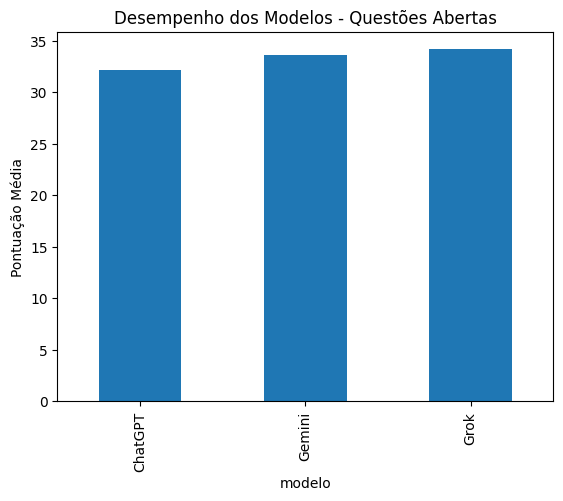

In [57]:
import matplotlib.pyplot as plt

# média por modelo (questões abertas)
media = df_avaliacao.groupby("modelo")["pontuacao_total"].mean()

media.plot(kind="bar")
plt.title("Desempenho dos Modelos - Questões Abertas")
plt.ylabel("Pontuação Média")
plt.show()

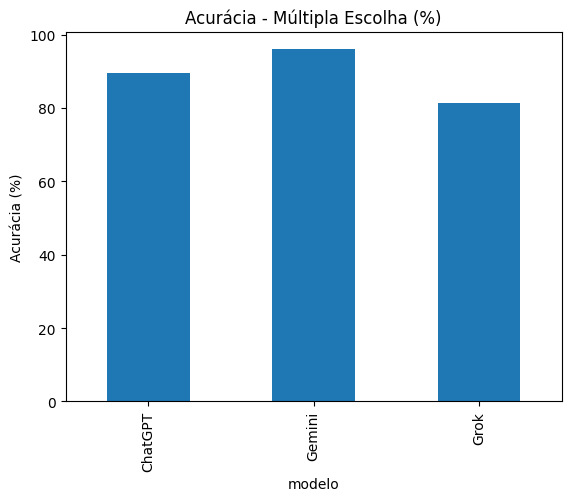

In [59]:
# acurácia múltipla escolha
acc = df_mc_respostas.groupby("modelo")["acertou"].mean() * 100

acc.plot(kind="bar")
plt.title("Acurácia - Múltipla Escolha (%)")
plt.ylabel("Acurácia (%)")
plt.show()